# TCAV 

## Concept Activation Vectors (CAV)

Please unzip the subfolders in the data folder and please them in the same data folder. 

In [117]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models

from torchvision import transforms
from PIL import Image

import sklearn
import numpy as np

import matplotlib.pyplot as plt

import glob
from PIL import Image

In [118]:
#! unzip data/strip.zip
#! unzip data/random_images.zip

### 1. First we load 50 strip concept images (from strip.zip) into a batch tensor `concept_tensor`.

In [119]:
image_list = []
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
for i, filename in enumerate(glob.glob('data/striped/*.jpg')):
    im=preprocess(Image.open(filename))
    image_list.append(im)

    if i == 19:
        break

concept_tensor = torch.stack(image_list)
concept_tensor.shape

torch.Size([20, 3, 224, 224])

### 2. Then we load 50 strip concept images (from strip.zip) into a batch tensor `confront_tensor`.

In [120]:
image_list = []
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

for i, filename in enumerate(glob.glob('data/imagenet_random_images/*.jpg')):
    im=preprocess(Image.open(filename))

    image_list.append(im)
    if i == 19:
        break

confront_tensor = torch.stack(image_list)
confront_tensor.shape

torch.Size([20, 3, 224, 224])

### 3. We use an activation hook in PyTorch to extract the intermediate activations from the final layer.



In [121]:
# Load a pre-trained VGG model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use device = xla.device() if you want to use tpu.
model = models.resnet50(pretrained=True).to(device)
# Set the model to evaluation mode
model.eval()

# Set all ReLU activations to inplace=False for gradient hooks
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

################################################################################

input_batch = torch.cat((concept_tensor, confront_tensor)).to(device)

# global dict to stock the hooks outputs
activation = {}

# Understand this part!
def get_activation(hook_name):
    def hook(module, input, output):
        activation[hook_name] = output.detach()
    return hook

# layer = model.layer4[-1]
layer = model.avgpool
handle_activation = layer.register_forward_hook(get_activation('conv'))

# global dict to stock the hooks outputs
gradient = {}

# Understand this part!
def get_gradient(hook_name):
    def hook(module, grad_input, grad_output):
        gradient[hook_name] = grad_output[0]
    return hook

# attach the hook to a given layer and save the reference to it in "handle_gradient"
handle_gradient = layer.register_full_backward_hook(get_gradient('conv'))


output = model(input_batch)
# _, idx = torch.max(output.data, 1)

/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### 4. We train a logistic regression classifier where we label images from `concept_tensor` as positive (1) and images from `confront_tensor` as negative (0). 
Given this we can extract the normal vector $ V_C $ of the separating hyperplane learned by the logistic classifier.



In [122]:
n = concept_tensor.shape[0]
y = torch.cat((torch.ones(concept_tensor.shape[0]), torch.zeros(confront_tensor.shape[0])))
X = torch.cat((activation['conv'][:n].view(n, -1), activation['conv'][n:].view(n, -1)))

clf = sklearn.linear_model.LogisticRegression().fit(X.cpu().numpy(), y.cpu().numpy())

normal_vector = clf.coef_[0]
print("Normal vector:", normal_vector)
# Predict labels for the test set
y_pred = clf.predict(X.cpu().numpy())

# Manually calculate accuracy
accuracy = np.mean(y_pred == y.cpu().numpy())
print("Accuracy:", accuracy)

Normal vector: [-0.01842889 -0.01625156 -0.01194479 ... -0.00754016  0.01109133
 -0.01844493]
Accuracy: 1.0


In [123]:
normal_vector = normal_vector - np.mean(normal_vector)
normal_vector = normal_vector / np.std(normal_vector)
print("Normalized normal vector:", normal_vector)

Normalized normal vector: [-0.73705761 -0.61972578 -0.38764178 ... -0.15028464  0.85373104
 -0.73792219]


### 5. We implement a backward hook in PyTorch to compute the gradient of the top-1 output logit of a ResNet model with respect to the same convolutional layer.

In [124]:
# check taylor paper been kim
normal_vector_reshaped = torch.tensor(normal_vector).reshape(1, -1, 1, 1).float().to(device)
# activation_dog = activation['conv'].clone()
# activation_pushed = activation_dog + normal_vector_reshaped

handle_activation.remove()
# handle_gradient.remove()

def modify_tensor(module, input, output):
    output = output + normal_vector_reshaped
    return output

hook_handle2 = model.avgpool.register_forward_hook(modify_tensor)
hook_handle2.remove()

### 6. We compute the `sensitivity score` as the scalar product between the normal vector $ V_C $ and the gradient from the previous question. 


In [125]:
import numpy as np

# 1) Normalize your normal vector once, immediately after computing it:
normal_vector = clf.coef_[0]
# center (optional) then L2‐normalize
normal_vector = normal_vector - normal_vector.mean()
normal_vector = normal_vector / np.linalg.norm(normal_vector)

# 2) In your helper function, normalize the gradient vector before the dot:
def compute_cosine_similarity_score(model, img_path, normal_vector, device):
    # load & preprocess as before…
    input_image = Image.open(img_path).convert("RGB")
    x = preprocess(input_image).unsqueeze(0).to(device)

    # forward & backward
    model.zero_grad()
    output = model(x)
    _, idx = torch.max(output, 1)
    output[0, idx].backward()

    # grab gradient and normalize it
    grad_vec = gradient['conv'].view(-1).cpu().numpy()
    grad_vec = grad_vec / np.linalg.norm(grad_vec)

    # now this is cosine similarity
    score = np.dot(normal_vector, grad_vec)
    return score

zebra_score = compute_cosine_similarity_score(model, 'data/zebra.jpg',
                                              normal_vector, device)
print(f"Zebra cosine‐similarity score: {zebra_score:.4f}")


tiger_Score = compute_cosine_similarity_score(model, 'data/tiger.jpg',
                                                normal_vector, device)
print(f"Tiger cosine‐similarity score: {tiger_Score:.4f}")


dog_score = compute_cosine_similarity_score(model, 'data/dog.jpg',
                                                normal_vector, device)
print(f"Dog cosine‐similarity score: {dog_score:.4f}")


Zebra cosine‐similarity score: 0.4342
Tiger cosine‐similarity score: 0.3245
Dog cosine‐similarity score: -0.0108


/var/folders/k7/xf0yhfbs02ggfm7n1l5g_cnm0000gn/T/ipykernel_99604/3372931710.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


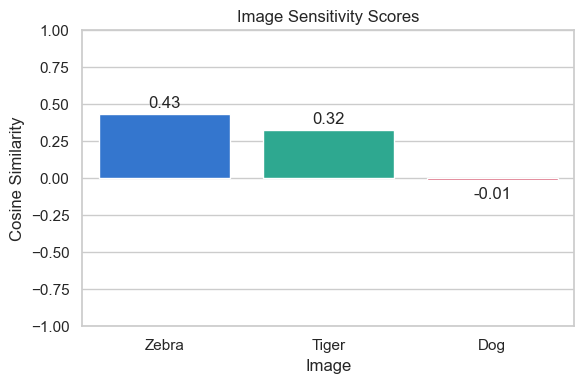

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Your scores
data = pd.DataFrame({
    'Image': ['Zebra', 'Tiger', 'Dog'],
    'CosineSimilarity': [0.4342, 0.3245, -0.0108]
})

# Define your book palette
book_palette = {
    'Zebra': '#1A73E8',       # bookBlue
    'Tiger': '#1ABC9C',       # bookTurquoise
    'Dog':   '#EA3356'        # bookPurple
}

sns.set_theme(style='whitegrid')
plt.figure(figsize=(6, 4))

# Create the barplot
ax = sns.barplot(
    data=data,
    x='Image',
    y='CosineSimilarity',
    palette=[book_palette[i] for i in data['Image']]
)

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + (0.02 if height >= 0 else -0.05),
        f"{height:.2f}",
        ha='center',
        va='bottom' if height >= 0 else 'top'
    )

ax.set(ylim=(-1, 1), ylabel='Cosine Similarity', title='Image Sensitivity Scores')
plt.tight_layout()
plt.show()
